In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import random
from collections import deque
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F

C_DQN  = "dodgerblue"
C_HEUR = "darkorange"

pi = np.pi

import drqn as dqn
import hex_world_procedural_senses as hex_world
import oracle_v2 as oracle

from sweep_fn_4 import *
from plot_fn_4 import *

ModuleNotFoundError: No module named 'hex_world_procedural_senses'

In [ ]:
import time
import numpy as np
import hex_world_cached as hex_world
import map_curriculum as mc

# ---- assumptions (edit) ----
RADIUS     = 20
N_SEEDS    = 8
SIM_LEN    = 1_000_000
EVAL_LEN   = 20_000
N_TIME     = 200                       # builds averaged per band
BANDS      = [(2, 4), (5, 7), (9, 11)] # easy / mid / hardest target
LIVES      = [50, 150, 500, 1000]      # candidate mean life lengths (ticks)
# ----------------------------

base_kwargs = {"radius": RADIUS}

def time_raw(band, n, max_attempts=200_000):
    """Mean wall-time per *successful* build, charging failed (degenerate)
    attempts to the total — this is the real cost the sim pays."""
    rng = np.random.default_rng(0)
    total, built, attempts, fails = 0.0, 0, 0, 0
    while built < n:
        attempts += 1
        if attempts > max_attempts:
            raise RuntimeError(f"band {band}: too many failures, world may be degenerate")
        s = int(rng.integers(0, 2**31 - 1))
        t0 = time.perf_counter()
        try:
            hex_world.HexWorld(seed=s, band=band, **base_kwargs)
        except ValueError:
            total += time.perf_counter() - t0
            fails += 1
            continue
        total += time.perf_counter() - t0
        built += 1
    return total / built, fails / max(1, built)

print(f"{'band':>8} {'ms/build':>10} {'fail/build':>11}")
per_build_s = {}
for band in BANDS:
    time_raw(band, 5)                       # warmup
    ms, failrate = time_raw(band, N_TIME)
    per_build_s[band] = ms
    print(f"{str(band):>8} {ms*1e3:>10.2f} {failrate:>11.2f}")

# curriculum builder at mid-ramp (adds seen-set + retry bookkeeping)
cur = mc.MapCurriculum(seed=0, base_env_kwargs=base_kwargs,
                       EB=SIM_LEN - EVAL_LEN, c_min=2, c_max=9, band_width=2)
for _ in range(5): cur.build(t=SIM_LEN // 2, eval_mode=False)
t0 = time.perf_counter()
for _ in range(N_TIME): cur.build(t=SIM_LEN // 2, eval_mode=False)
print(f"\nMapCurriculum.build (mid window): {(time.perf_counter()-t0)\n_TIME*1e3:.2f} ms/build")

worst = max(per_build_s.values())           # hardest band dominates
print(f"\nworst per-build: {worst*1e3:.2f} ms  (band {max(per_build_s, key=per_build_s.get)})")
print(f"\n--- build overhead, {N_SEEDS} seeds x {SIM_LEN:,} ticks, tpm=1 ---")
print(f"{'mean life':>10} {'builds/seed':>12} {'total builds':>13} {'overhead':>12} {'/seed':>9}")
for life in LIVES:
    bps = int(np.ceil(SIM_LEN / life))
    tot = bps * N_SEEDS
    secs = tot * worst
    print(f"{life:>10} {bps:>12,} {tot:>13,} {secs/60:>9.1f} min {secs\n_SEEDS/60:>6.1f} m")

    band   ms/build  fail/build
  (2, 4)      18.14        0.00
  (5, 7)      16.72        0.00
 (9, 11)      16.68        0.00

MapCurriculum.build (mid window): 18.56 ms/build

worst per-build: 18.14 ms  (band (2, 4))

--- build overhead, 8 seeds x 1,000,000 ticks, tpm=1 ---
 mean life  builds/seed  total builds     overhead     /seed
        50       20,000       160,000      48.4 min    6.0 m
       150        6,667        53,336      16.1 min    2.0 m
       500        2,000        16,000       4.8 min    0.6 m
      1000        1,000         8,000       2.4 min    0.3 m


In [ ]:
import time, importlib
import sim_instance_v2 as siv2
importlib.reload(siv2)

PILOT = 100_000
EK = {"radius": 20}          # your env_kwargs (band is set by the curriculum)

t0 = time.perf_counter()
r0 = siv2.sim_instance(seed=0, sim_len=PILOT, eval_len=5_000,
                       curriculum_mode="disabled",
                       env_kwargs={**EK, "band": (9, 11)})
sim_only = time.perf_counter() - t0

t0 = time.perf_counter()
r1 = siv2.sim_instance(seed=0, sim_len=PILOT, eval_len=5_000,
                       curriculum_mode="band", env_kwargs=EK)
sim_plus = time.perf_counter() - t0

builds = r1["n_train_maps"] + r1["n_eval_maps"]
scale  = 1_000_000 / PILOT

print(f"pilot {PILOT:,} ticks")
print(f"  sim only (disabled) : {sim_only:6.1f} s")
print(f"  sim + builds (band) : {sim_plus:6.1f} s   builds={builds}")
print(f"  build overhead      : {sim_plus-sim_only:6.1f} s  "
      f"({(sim_plus-sim_only)/sim_plus*100:.0f}% of wall)")
print()
print(f"projected 1M (x{scale:.0f}; ramp loads deadlier maps late, so a slight UNDER-estimate):")
print(f"  per seed       : {sim_plus*scale/60:6.1f} min "
      f"(sim {sim_only*scale/60:.1f} + builds {(sim_plus-sim_only)*scale/60:.1f})")
print(f"  8 seeds serial : {sim_plus*scale*8/3600:6.2f} h")

In [ ]:
import pickle, hex_world_cached as hex_world
w = hex_world.HexWorld(seed=0, band=(9,11), radius=20)
print(f"~{len(pickle.dumps(w))/1024:.0f} KB/map  ->  ~{len(pickle.dumps(w))*3000/1e6:.0f} MB for 3000")

In [ ]:
import time, numpy as np, hex_world_cached as hw

def scaffold_only(band, radius=20, n=50):
    t = 0.0
    for _ in range(n):
        t0 = time.perf_counter()
        coords = hw.HexWorld._make_coords(radius)
        cset = set(coords)
        cand = [c for c in coords
                if hw.HexWorld.hex_dist(c, (0,0)) <= radius - 1
                and any(nb in cset for nb in hw.HexWorld.hex_neighbors(c, band[0], band[1]))]
        t += time.perf_counter() - t0
    return t / n

def full(band, radius=20, n=50):
    rng = np.random.default_rng(1); t = 0.0; b = 0
    while b < n:
        s = int(rng.integers(0, 2**31 - 1)); t0 = time.perf_counter()
        try: hw.HexWorld(seed=s, band=band, radius=radius)
        except ValueError: t += time.perf_counter()-t0; continue
        t += time.perf_counter()-t0; b += 1
    return t / n

sc, fl = scaffold_only((9,11)), full((9,11))
print(f"scaffold {sc*1e3:.1f} ms | full {fl*1e3:.1f} ms | scaffold = {sc/fl*100:.0f}% of build")
print(f"Bridson+food residual ~{(fl-sc)*1e3:.1f} ms")

In [ ]:
import time, importlib
import numpy as np
import map_curriculum
import sim_instance_v2 as siv2
importlib.reload(map_curriculum)
importlib.reload(siv2)

EK = {"radius": 20}
COMMON = dict(
    model_type="noisy_DQN", n_step=10,
    senses=("vision", "smell"),
    novelty_rewards=True, beta=0.05, beta_anneal=True,
    replay_archive_len=50000,
    curriculum_mode="band", c_min=2, c_max=9, band_width=2,
    terminals_per_map=1, life_cap=1000,
    env_kwargs=EK,
)

def check(name, cond):
    print(f"  {'PASS' if cond else 'FAIL':>4}  {name}")
    if not cond:
        raise AssertionError(name)

# --- 0. cache wired into the BUILD HOT PATH (the thing that bit us last time) ---
hw = map_curriculum.hex_world                      # whatever module the curriculum builds through
print("build-path hexworld:", hw.__name__)
check("build path uses the cached hexworld", hasattr(hw, "_SCAFFOLD_CACHE"))
hw._SCAFFOLD_CACHE.clear()

# --- 1. held-out firewall: train/eval map seeds must be disjoint ---
cur = map_curriculum.MapCurriculum(seed=0, base_env_kwargs=EK, EB=24000)
train_seeds = {cur.build(t=12000)[2] for _ in range(50)}
eval_seeds  = {cur.build(t=24000, eval_mode=True)[2] for _ in range(50)}
check("train/eval map seeds disjoint (eval is held out)", train_seeds.isdisjoint(eval_seeds))

# --- 2. main band run: resampling, eval segmentation, frozen decay, no NaN ---
SMOKE = 40000
hw._SCAFFOLD_CACHE.clear()
t0 = time.perf_counter()
r = siv2.sim_instance(seed=0, sim_len=SMOKE, eval_len=8000, **COMMON)
dt = time.perf_counter() - t0
print(f"\nband {SMOKE} ticks in {dt:.1f}s  (slow = cache NOT wired)")
print(f"  maps train={r['n_train_maps']} eval={r['n_eval_maps']} | "
      f"deaths={r['death_count']} timeouts={r['n_timeouts']} | "
      f"wf={r['train_wf_trips']} fw={r['train_fw_trips']}")
print(f"  decay_band={r['decay_band']} | eval_segments={len(r['eval_segments'])} | "
      f"scaffolds_cached={len(hw._SCAFFOLD_CACHE)}")
print(f"  mean_comfort_eval={r['mean_comfort']:.3f} death_rate_eval={r['death_rate_eval']:.4f}")

check("training resampled maps", r["n_train_maps"] > 1)
check("eval built held-out maps", r["n_eval_maps"] > 1)
check("eval segments recorded", len(r["eval_segments"]) >= 2)
check("decay frozen at hard band (9,11)", tuple(r["decay_band"]) == (9, 11))
check("scaffold cache populated during run", len(hw._SCAFFOLD_CACHE) >= 1)
check("comfort finite (no NaN from boundary flush)", np.isfinite(r["comfort_T"]).all())
check("death_T counts deaths only", r["death_count"] == int(r["death_T"].sum()))
w0 = set(map(tuple, r["eval_segments"][0]["water_coords"]))
w1 = set(map(tuple, r["eval_segments"][1]["water_coords"]))
check("eval maps actually change between segments", w0 != w1)

# --- 3. timeout terminal: low life_cap must fire it; None must disable it ---
rt = siv2.sim_instance(seed=0, sim_len=8000, eval_len=2000, **{**COMMON, "life_cap": 30})
rn = siv2.sim_instance(seed=0, sim_len=8000, eval_len=2000, **{**COMMON, "life_cap": None})
print(f"\nlife_cap=30 -> timeouts={rt['n_timeouts']} | life_cap=None -> timeouts={rn['n_timeouts']}")
check("timeout terminal fires at low life_cap", rt["n_timeouts"] > 0)
check("life_cap=None disables timeouts", rn["n_timeouts"] == 0)
check("timeouts never logged as deaths", rt["death_count"] == int(rt["death_T"].sum()))

# --- 4. disabled-mode parity (Proto 04 path stays intact) ---
rd = siv2.sim_instance(seed=0, sim_len=8000, eval_len=2000,
                       model_type="noisy_DQN", n_step=10,
                       curriculum_mode="disabled", env_kwargs={**EK, "band": (9, 11)})
check("disabled mode runs clean", np.isfinite(rd["comfort_T"]).all())
check("disabled mode never resamples", rd["n_train_maps"] == 1)
check("disabled mode has no timeouts", rd["n_timeouts"] == 0)

# --- projection ---
per_seed = dt * (1_000_000 / SMOKE)
print(f"\nprojected 1M/seed ~{per_seed/60:.1f} min | "
      f"8 seeds 4-way ~{per_seed*8/4/60:.0f} min wall")
print("\nSMOKE OK")

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import sim_instance_v2 as siv2

EK = {"radius": 20}
LEARN_EVERY = 20
SIM_LEN, EVAL_LEN = 150_000, 20_000
EB = SIM_LEN - EVAL_LEN

COMMON = dict(
    model_type="noisy_DQN", n_step=10, senses=("vision", "smell"),
    novelty_rewards=True, beta=0.05, beta_anneal=True, replay_archive_len=50000,
    curriculum_mode="band", c_min=2, c_max=9, band_width=2,
    terminals_per_map=1, life_cap=1000, env_kwargs=EK,
)

t0 = time.perf_counter()
r = siv2.sim_instance(seed=0, sim_len=SIM_LEN, eval_len=EVAL_LEN, **COMMON)
print(f"ran {SIM_LEN} ticks in {(time.perf_counter()-t0)/60:.1f} min | "
      f"maps={r['n_train_maps']} deaths={r['death_count']} timeouts={r['n_timeouts']} "
      f"wf={r['train_wf_trips']} fw={r['train_fw_trips']}")

def roll(x, w):
    x = np.asarray(x, float)
    if len(x) < w:
        return np.arange(len(x)), x
    c = np.cumsum(np.insert(x, 0, 0.0))
    y = (c[w:] - c[:-w]) / w
    return np.arange(w - 1, len(x)), y

def thin(idx, y, n=4000):                      # keep plots light
    if len(idx) <= n:
        return idx, y
    k = len(idx) // n
    return idx[::k], y[::k]

comfort = np.asarray(r["comfort_T"])
death = np.asarray(r["death_T"], float)
sigma = np.asarray(r["sigma_w_mean"], float)

cw, dw = 2000, 5000
ci, cy = thin(*roll(comfort, cw))
di, dy = thin(*roll(death, dw))
sx = np.arange(len(sigma)) * LEARN_EVERY       # sigma logged every LEARN_EVERY ticks, train only
_, sy = thin(np.arange(len(sigma)), sigma, n=3000)
sx = sx[:len(sy)*max(1, len(sigma)//len(sy)):max(1, len(sigma)//len(sy))][:len(sy)] if len(sigma) > 3000 else sx

fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=False)

ax[0].plot(sx, sy, lw=0.9, color="tab:purple")
ax[0].set_title(f"noisy sigma_w (train only) — rises on this task (no anneal); watch for collapse/explosion")
ax[0].set_xlabel("tick"); ax[0].set_ylabel("mean |sigma_w|")

ax[1].plot(ci, cy, lw=1.0, color="tab:blue")
ax[1].axvline(EB, color="k", ls="--", lw=0.8)
ax[1].text(EB, ax[1].get_ylim()[0], " eval", va="bottom", fontsize=8)
ax[1].set_title(f"comfort (rolling {cw}) — trending up = learning; flat = nothing")
ax[1].set_xlabel("tick"); ax[1].set_ylabel("comfort")

ax[2].plot(di, dy, lw=1.0, color="tab:red")
ax[2].axvline(EB, color="k", ls="--", lw=0.8)
ax[2].axhline(r["death_rate_eval"], color="gray", ls=":", lw=0.8)
ax[2].text(0, r["death_rate_eval"], f" eval death-rate {r['death_rate_eval']:.4f}", va="bottom", fontsize=8)
ax[2].set_title(f"death rate (rolling {dw}) — trending down = surviving")
ax[2].set_xlabel("tick"); ax[2].set_ylabel("deaths / tick")

plt.tight_layout(); plt.show()

# numbers, not eyeballs: early vs late TRAINING window
seg = 20_000
e_c, l_c = comfort[:seg].mean(), comfort[EB-seg:EB].mean()
e_d, l_d = death[:seg].mean(), death[EB-seg:EB].mean()
print(f"comfort  early {e_c:+.3f} -> late {l_c:+.3f}  (delta {l_c-e_c:+.3f})")
print(f"death/tk early {e_d:.4f} -> late {l_d:.4f}  (delta {l_d-e_d:+.4f})")
print(f"sigma_w  start {sigma[0]:.4f} -> end {sigma[-1]:.4f}")

In [ ]:
import numpy as np
co = np.asarray(r["coordinates_T"]); EB = r["eval_boundary"]
death = np.asarray(r["death_T"]); segs = r["eval_segments"]

w, f = r["ticks_at_water_eval"], r["ticks_at_food_eval"]
de = int(death[EB:].sum()); to = r["n_timeouts_eval"]
print(f"eval water:food ticks = {w}:{f}  ({w/max(1,f):.1f}:1)   [Proto04 campers ~25:1]")
print(f"eval deaths={de} timeouts={to}  timeout share={to/max(1,de+to):.2f}")

bounds = [s["t_start"] for s in segs] + [len(co)]
twf = tfw = lives_trip = 0
for k, s in enumerate(segs):
    a, b = bounds[k], bounds[k+1]
    wset = set(map(tuple, s["water_coords"])); fset = set(map(tuple, s["food_coords"]))
    last = None; wf = fw = 0
    for c in co[a:b]:
        c = tuple(c)
        if c in wset:
            if last == "f": fw += 1
            last = "w"
        elif c in fset:
            if last == "w": wf += 1
            last = "f"
    twf += wf; tfw += fw
    if wf and fw: lives_trip += 1
print(f"eval crossings wf={twf} fw={tfw} | held-out maps with a round trip: {lives_trip}/{len(segs)}")

In [ ]:
import numpy as np
from sim_instance_v2 import sim_instance
EK = dict(radius=20)

# oracle alive + comfort baseline (curriculum OFF for a clean fixed map read)
r = sim_instance(seed=0, model_type="oracle", curriculum_mode="disabled",
                 env_kwargs=dict(radius=20, band=(9,11)),
                 sim_len=40000, eval_len=20000, novelty_rewards=False)

c = r["comfort_T"][r["eval_boundary"]:]
print(f"oracle mean_comfort={c.mean():.3f}  min={c.min():.3f}  deaths={r['death_count_eval']}")
print(f"  ticks_at_water={r['ticks_at_water_eval']}  ticks_at_food={r['ticks_at_food_eval']}")

    [seed 0] t=0 deaths=0 timeouts=0 maps=1 wf=0 fw=0
oracle mean_comfort=0.802  min=0.522  deaths=0
  ticks_at_water=16758  ticks_at_food=630


: 

In [5]:
import numpy as np
import hex_world_cached as hw

w = hw.HexWorld(seed=7, band=(9,11), radius=20)
f = w.food_coords[0]
w.reset_position(coord=f)
m = w.get_action_mask()
print("on a FOOD tile", f)
print("  eat actions legal (idx 4-6):", m[4:7], "-> any:", m[4:7].any())
print("  node food level here       :", w.nodes[f]["food"])
w.reset_position(coord=w.water_coords[0])
print("on a WATER tile: drink legal  :", w.get_action_mask()[1:4].any(),
      "| node water:", w.nodes[w.water_coords[0]]["water"])

on a FOOD tile (14, -8)
  eat actions legal (idx 4-6): [ True  True  True] -> any: True
  node food level here       : 1.0
on a WATER tile: drink legal  : True | node water: 1.0


running seed 7 (unslimmed)…
    [seed 7] t=0 deaths=0 timeouts=0 maps=1 wf=0 fw=0
    [seed 7] t=50000 deaths=2168 timeouts=0 maps=2169 wf=121 fw=88
    [seed 7] t=100000 deaths=4088 timeouts=0 maps=4089 wf=248 fw=166
    [seed 7] t=150000 deaths=5904 timeouts=0 maps=5905 wf=367 fw=230
    [seed 7] t=200000 deaths=7620 timeouts=0 maps=7621 wf=468 fw=277
    [seed 7] t=250000 deaths=8979 timeouts=0 maps=8980 wf=579 fw=350
    [seed 7] t=300000 deaths=10359 timeouts=0 maps=10360 wf=655 fw=411
    [seed 7] t=350000 deaths=11566 timeouts=0 maps=11567 wf=746 fw=468
    [seed 7] t=400000 deaths=12623 timeouts=0 maps=12624 wf=830 fw=524
    [seed 7] t=450000 deaths=13627 timeouts=0 maps=13628 wf=888 fw=564
    [seed 7] t=500000 deaths=14548 timeouts=0 maps=14549 wf=940 fw=603
    [seed 7] t=550000 deaths=15462 timeouts=0 maps=15463 wf=995 fw=632
    [seed 7] t=600000 deaths=16359 timeouts=0 maps=16360 wf=1028 fw=658
    [seed 7] t=650000 deaths=17186 timeouts=0 maps=17187 wf=1062 fw=679
    [

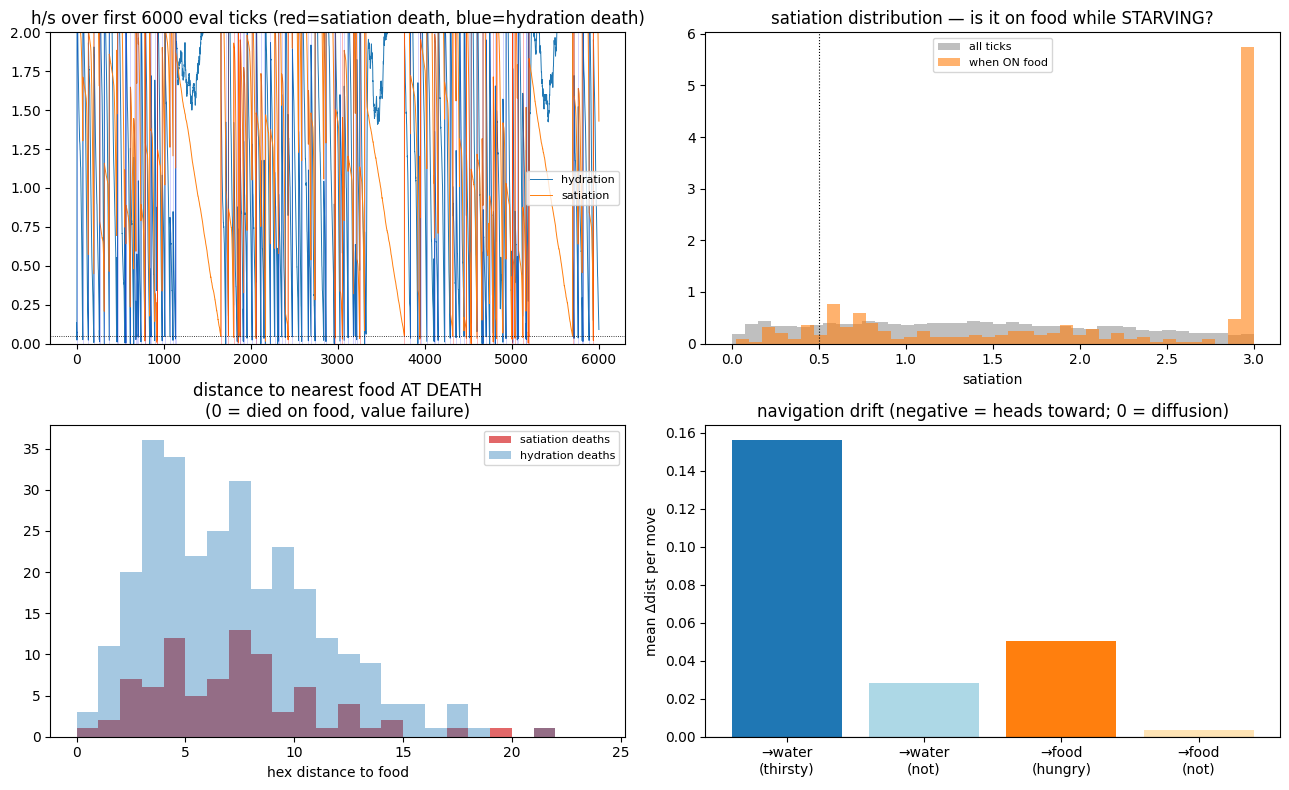

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import map_curriculum, hex_world_cached
from sim_instance_v2 import sim_instance

SEED, CFG = 7, "beta_floor_0"

# --- config: stored hyperparams from the CSV + the known sweep constants ---
row = pd.read_csv("results/sweeps/05_generalisation__betafloor_camping_break_n10/runs_df.csv").query("config==@CFG and seed==@SEED").iloc[0]
cfg = dict(
    sim_len=int(row.sim_len), eval_len=int(row.eval_len),
    env_kwargs=dict(radius=int(row.radius)),
    batch_size=int(row.batch_size), gamma=float(row.gamma),
    epsilon_start=float(row.epsilon_start),
    replay_archive_len=int(row.buffer), replay_warmup=int(row.warmup),
    update_ticks=int(row.update_ticks), learn_every=int(row.learn_every),
    # --- VERIFY these match your betafloor sweep ---
    model_type="noisy_DQN", n_step=10, sigma_0=0.5,
    senses=("smell", "vision"), novelty_rewards=True,
    beta=0.1, beta_floor=0.0,
    curriculum_mode="band", c_min=2, c_max=9, band_width=2,
    curriculum_ramp_frac=0.6, terminals_per_map=1, life_cap=1000,
)
print("running seed 7 (unslimmed)…")
r = sim_instance(seed=SEED, **cfg)

EB = r["eval_boundary"]
co = np.asarray(r["coordinates_T"])[EB:]
hyd = np.asarray(r["hydration_T"])[EB:]; sat = np.asarray(r["satiation_T"])[EB:]
act = np.asarray(r["action_T"])[EB:];   death = np.asarray(r["death_T"])[EB:]
segs = r["eval_segments"]; n = len(co)

# --- reproduction check vs CSV ---
wv = r["ticks_at_water_eval"]\n*100; fv = r["ticks_at_food_eval"]\n*100
print(f"\nrepro: eval_deaths {r['death_count_eval']} (csv {int(row.eval_deaths)}) | "
      f"water% {wv:.2f} (csv {row.water_visit_pct:.2f}) | food% {fv:.2f} (csv {row.food_visit_pct:.2f})")
print("  -> if these are far off, the config above doesn't match the sweep\n")

# --- per-tick: on-resource + distance-to-nearest, using the active eval map ---
is_eat  = np.isin(act, [4,5,6]); is_drink = np.isin(act, [1,2,3]); is_move = act >= 7
on_food = np.zeros(n, bool); on_water = np.zeros(n, bool)
dist_food = np.full(n, np.nan); dist_water = np.full(n, np.nan)

def hexmin(c, arr):
    dq = arr[:,0]-c[0]; dr = arr[:,1]-c[1]; ds = -dq-dr
    return np.maximum(np.maximum(np.abs(dq), np.abs(dr)), np.abs(ds)).min()

bounds = [s["t_start"] for s in segs] + [EB + n]
for k, s in enumerate(segs):
    a = max(0, bounds[k]-EB); b = min(n, bounds[k+1]-EB)
    if b <= a: continue
    farr = np.array(s["food_coords"]); warr = np.array(s["water_coords"])
    fset = set(map(tuple, s["food_coords"])); wset = set(map(tuple, s["water_coords"]))
    for i in range(a, b):
        c = (int(co[i,0]), int(co[i,1]))
        on_food[i] = c in fset; on_water[i] = c in wset
        dist_food[i] = hexmin(c, farr); dist_water[i] = hexmin(c, warr)

# --- 1. affordance asymmetry, conditioned on NEED ---
def rate(mask, act_mask): return act_mask[mask].mean() if mask.any() else np.nan
hungry_food = on_food & (sat < 0.5); thirsty_water = on_water & (hyd < 0.5)
print("AFFORDANCE (does it use the resource it's standing on?)")
print(f"  on food: {on_food.sum():5d} ticks | eat-rate {rate(on_food,is_eat):.3f} | "
      f"eat-rate WHEN HUNGRY {rate(hungry_food,is_eat):.3f} | mean satiation here {sat[on_food].mean():.2f}")
print(f"  on water:{on_water.sum():5d} ticks | drink-rate {rate(on_water,is_drink):.3f} | "
      f"drink-rate WHEN THIRSTY {rate(thirsty_water,is_drink):.3f} | mean hydration here {hyd[on_water].mean():.2f}")

# --- 2. death anatomy: cause + distance to food ---
d = np.where(death == 1)[0]
sat_d = d[(sat[d] <= 0.06) & (hyd[d] > 0.06)]
hyd_d = d[(hyd[d] <= 0.06) & (sat[d] > 0.06)]
both_d = d[(hyd[d] <= 0.06) & (sat[d] <= 0.06)]
print(f"\nDEATHS: satiation {len(sat_d)} | hydration {len(hyd_d)} | both {len(both_d)}")
if len(sat_d):
    print(f"  dist-to-food at satiation deaths: median {np.median(dist_food[sat_d]):.1f} "
          f"(0 = died ON food and didn't eat → value failure; large = never reached food)")

# --- 3. navigation vs diffusion: does it drift toward need? (random walk ≈ 0) ---
ddw = np.diff(dist_water); ddf = np.diff(dist_food); mv = is_move[:-1]
th = hyd[:-1] < 0.4; hu = sat[:-1] < 0.4
def drift(dd, m): sel = mv & m; return dd[sel].mean() if sel.any() else np.nan
print("\nNAVIGATION drift (Δdist per move; negative = heading toward; ~0 = diffusion)")
print(f"  toward WATER when thirsty {drift(ddw, th):+.3f} | when not {drift(ddw, ~th):+.3f}")
print(f"  toward FOOD  when hungry  {drift(ddf, hu):+.3f} | when not {drift(ddf, ~hu):+.3f}")

# --- plots ---
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
W = min(6000, n)
ax[0,0].plot(hyd[:W], lw=0.7, label="hydration", color="tab:blue")
ax[0,0].plot(sat[:W], lw=0.7, label="satiation", color="tab:orange")
for i in sat_d[sat_d < W]: ax[0,0].axvline(i, color="red", lw=0.4, alpha=0.5)
for i in hyd_d[hyd_d < W]: ax[0,0].axvline(i, color="blue", lw=0.4, alpha=0.3)
ax[0,0].axhline(0.05, color="k", ls=":", lw=0.6)
ax[0,0].set_title(f"h/s over first {W} eval ticks (red=satiation death, blue=hydration death)")
ax[0,0].legend(fontsize=8); ax[0,0].set_ylim(0, 2)

ax[0,1].hist(sat, bins=40, alpha=0.5, density=True, label="all ticks", color="gray")
if on_food.any():
    ax[0,1].hist(sat[on_food], bins=40, alpha=0.6, density=True, label="when ON food", color="tab:orange")
ax[0,1].axvline(0.5, color="k", ls=":", lw=0.8)
ax[0,1].set_title("satiation distribution — is it on food while STARVING?")
ax[0,1].set_xlabel("satiation"); ax[0,1].legend(fontsize=8)

if len(sat_d):
    ax[1,0].hist(dist_food[sat_d], bins=range(0, 25), alpha=0.7, color="tab:red", label="satiation deaths")
if len(hyd_d):
    ax[1,0].hist(dist_food[hyd_d], bins=range(0, 25), alpha=0.4, color="tab:blue", label="hydration deaths")
ax[1,0].set_title("distance to nearest food AT DEATH\n(0 = died on food, value failure)")
ax[1,0].set_xlabel("hex distance to food"); ax[1,0].legend(fontsize=8)

bars = [drift(ddw, th), drift(ddw, ~th), drift(ddf, hu), drift(ddf, ~hu)]
labels = ["→water\n(thirsty)", "→water\n(not)", "→food\n(hungry)", "→food\n(not)"]
cols = ["tab:blue","lightblue","tab:orange","moccasin"]
ax[1,1].bar(labels, bars, color=cols); ax[1,1].axhline(0, color="k", lw=0.8)
ax[1,1].set_title("navigation drift (negative = heads toward; 0 = diffusion)")
ax[1,1].set_ylabel("mean Δdist per move")
plt.tight_layout(); plt.show()

In [ ]:
# ── smoke: touch_memory wiring ──────────────────────────────────────────────
# (1) feature\n_INPUT shape  (2) displacement renders right  (3) reset clears it.
# Replicates make_agent_state — keep this block character-identical to the sim.

import numpy as np
import map_curriculum as mc

SENSES   = {"vision", "smell", "touch_memory"}
MEM_KEY  = "touch_memory"
R_TEST   = 20
env_kwargs = dict(radius=R_TEST)

# build a real map the way sim_instance does
curr = mc.MapCurriculum(seed=0, base_env_kwargs=env_kwargs, EB=1, c_min=2, c_max=9,
                        band_width=2, ramp_frac=0.6, sampling="uniform")
env, _, _ = curr.build(t=0, eval_mode=False)

# --- N_INPUT, exactly as the sim computes it ---
memory_len = 10
BASE_INPUT = 6 + memory_len * 3
VIS = 2 + 6 * 3 if "vision" in SENSES else 0
SML = 1          if "smell"  in SENSES else 0
MEM = 6          if MEM_KEY  in SENSES else 0
N_INPUT = BASE_INPUT + VIS + SML + MEM

# --- replicate make_agent_state (memory state passed in) ---
m_que_d = [0]*memory_len; m_que_e = [0]*memory_len; m_que_m = [-1]*memory_len
def agent_state(h, s, b, last_water_seen, last_food_seen):
    parts = [np.asarray(env.make_state(h, s, b, m_que_d, m_que_e, m_que_m), dtype=np.float32)]
    if "vision" in SENSES:
        parts.append(env.get_vision_features())
    if "smell" in SENSES:
        parts.append(np.array([env.get_food_smell(radius=3)], dtype=np.float32))
    if MEM_KEY in SENSES:
        cq, cr = env.coord
        R = env.radius
        if last_water_seen is None:
            wq, wr, wf = 0., 0., 0.
        else:
            wq, wr, wf = (last_water_seen[0]-cq)/R, (last_water_seen[1]-cr)/R, 1.
        if last_food_seen is None:
            fq, fr, ff = 0., 0., 0.
        else:
            fq, fr, ff = (last_food_seen[0]-cq)/R, (last_food_seen[1]-cr)/R, 1.
        parts.append(np.array([wq, wr, wf, fq, fr, ff], dtype=np.float32))
    return np.concatenate(parts).astype(np.float32)

# (1) SHAPE — blind state must equal N_INPUT, and memory slice must be zeros
x_blind  = agent_state(1.0, 1.0, 0.5, None, None)
mem_blind = x_blind[-MEM:]
assert len(x_blind) == N_INPUT, f"shape mismatch: {len(x_blind)} vs N_INPUT={N_INPUT}"
assert MEM == 6 and np.allclose(mem_blind, 0.0), f"blind memory not zero: {mem_blind}"

# (2) DISPLACEMENT — stand far from a water tile so disp ≠ absolute and |disp| can exceed 1
w = tuple(map(int, env.water_coords[0]))
f = tuple(map(int, env.food_coords[0]))
far = max((tuple(c) for c in env.coords),
          key=lambda c: max(abs(c[0]-w[0]), abs(c[1]-w[1])))   # tile far from water
env.reset_position(coord=far)
cq, cr = env.coord
assert (cq, cr) != (0, 0), "agent at origin — displacement test degenerate"

x_seen   = agent_state(1.0, 1.0, 0.5, w, f)
mem_seen = x_seen[-MEM:]
assert np.isclose(mem_seen[0], (w[0]-cq)/env.radius), f"q disp wrong: {mem_seen[0]} vs {(w[0]-cq)/env.radius}"
assert np.isclose(mem_seen[1], (w[1]-cr)/env.radius), f"r disp wrong: {mem_seen[1]} vs {(w[1]-cr)/env.radius}"
assert mem_seen[2] == 1.0 and mem_seen[5] == 1.0,     f"seen-flags not set: {mem_seen}"
assert not np.allclose(mem_blind, mem_seen),          "blind and seen identical — memory inert"

# (3) RESET — memory must wipe back to zeros
x_reset = agent_state(1.0, 1.0, 0.5, None, None)
assert np.allclose(x_reset[-MEM:], 0.0), "memory not cleared on reset"

beyond1 = np.abs(mem_seen[:2]).max() > 1.0
print(f"OK  N_INPUT={N_INPUT}")
print(f"    mem_blind = {mem_blind}")
print(f"    mem_seen  = {mem_seen}   (|disp|>1 reached: {beyond1})")

OK  N_INPUT=63
    mem_blind = [0. 0. 0. 0. 0. 0.]
    mem_seen  = [ 0.8  -1.75  1.    0.95 -1.85  1.  ]   (|disp|>1 reached: True)


In [15]:
from sweep_fn_v5 import load_pickle, compute_eval_metrics

run = load_pickle("results/sweeps/05_generalisation__decay_on_radius_v1/runs/terminals_per_map_1__seed1.pkl")
eb = run["eval_boundary"]
segs = run["eval_segments"]
print("n segments:", len(segs))
print("first 5 local starts:", [s["t_start"] - eb for s in segs][:5])
print("last local start:", segs[-1]["t_start"] - eb, "vs eval len:", run["eval_boundary"] and len(run["coordinates_T"]) - eb)
m = compute_eval_metrics(run, run.get("env_kwargs", {}))
print("n_eval_segments in metrics:", m.get("n_eval_segments"))
print("eat_rate_at_food:", m.get("eat_rate_at_food"))
print("two_way_route_success_min:", m.get("two_way_route_success_min"))

print(m["water_to_food_success_rate"], m["water_to_food_success_count"], m["water_to_food_trip_count"])
print(m["food_to_water_success_rate"], m["food_to_water_success_count"], m["food_to_water_trip_count"])

n segments: 115
first 5 local starts: [0, 123, 213, 278, 286]
last local start: 19817 vs eval len: 20000
n_eval_segments in metrics: 115
eat_rate_at_food: 0.739938080495356
two_way_route_success_min: 0.0004621072088724584
0.0004621072088724584 1 2164
0.03278688524590164 2 61


In [2]:
# ── H1 failure-reason split: where do wf trips die? ──────────────────────────
from pathlib import Path
import numpy as np
from sweep_fn_v5 import load_pickle, compute_eval_metrics

RUNS = Path("results/sweeps/05_generalisation__touch_memory_v1/runs")
paths = sorted(RUNS.glob("*.pkl"))
assert paths, f"no pkls found in {RUNS.resolve()}"

REASONS = ["success", "returned_source", "timeout", "death"]

def reason_row(m, prefix):
    row = {
        "success":         m[f"{prefix}_success_count"],
        "returned_source": m[f"{prefix}_returned_source_count"],
        "timeout":         m[f"{prefix}_timeout_count"],
        "death":           m[f"{prefix}_death_count"],
    }
    total = sum(row.values())
    assert total == m[f"{prefix}_trip_count"], \
        f"{prefix}: reasons sum {total} != trip_count {m[f'{prefix}_trip_count']}"
    return row, total

pooled = {}  # arm -> direction -> reason counts
print(f"{'config':<34}{'seed':>4}  {'dir':<3}{'trips':>7}"
      + "".join(f"{r:>17}" for r in REASONS))

for p in paths:
    run = load_pickle(p)
    m = compute_eval_metrics(run, run.get("env_kwargs", {}))
    arm, seed = run["config_name"], run["seed"]
    for d, prefix in [("wf", "water_to_food"), ("fw", "food_to_water")]:
        row, total = reason_row(m, prefix)
        acc = pooled.setdefault(arm, {}).setdefault(d, dict.fromkeys(REASONS, 0))
        for r in REASONS: acc[r] += row[r]
        print(f"{arm:<34}{seed:>4}  {d:<3}{total:>7}"
              + "".join(f"{row[r]:>7} ({row[r]/max(total,1):>6.1%})" for r in REASONS))

print("\n── pooled per arm ──")
for arm, dirs in pooled.items():
    for d, acc in dirs.items():
        total = sum(acc.values())
        print(f"{arm:<34}      {d:<3}{total:>7}"
              + "".join(f"{acc[r]:>7} ({acc[r]/max(total,1):>6.1%})" for r in REASONS))
        
# ── penetration depth: how far do failed wf departures actually get? ────────
from sweep_fn_v5 import (load_pickle, extract_resource_trips, get_eval_array,
                         hex_dist, eval_boundary)
import numpy as np
from pathlib import Path

for p in sorted(Path("results/sweeps/05_generalisation__touch_memory_v1/runs").glob("*.pkl")):
    run = load_pickle(p)
    segs = run["eval_segments"]
    eb = eval_boundary(run)
    co_all = np.asarray(get_eval_array(run, "coordinates_T", "coordinates_eval"), dtype=int)
    de_all = np.asarray(get_eval_array(run, "death_T", "death_eval")).astype(bool)

    depths = []
    for i, seg in enumerate(segs):
        a = max(0, int(seg["t_start"]) - eb)
        z = (int(segs[i + 1]["t_start"]) - eb) if i + 1 < len(segs) else len(co_all)
        z = min(len(co_all), z)
        if z <= a:
            continue
        co, de = co_all[a:z], de_all[a:z]
        wset = set(map(tuple, seg["water_coords"]))
        for tr in extract_resource_trips(co, de, seg["water_coords"], seg["food_coords"]):
            if tr["success"]:
                continue
            path = co[tr["start"]:tr["end"] + 1]
            d = max(min(hex_dist(tuple(c), w) for w in wset) for c in map(tuple, path))
            depths.append(d)

    depths = np.array(depths)
    assert len(depths), f"{p.name}: no failed trips found — slicing is wrong"
    print(f"{run['config_name']:<34}s{run['seed']}  failed={len(depths):>5}  "
          f"med={np.median(depths):.0f}  p90={np.percentile(depths,90):.0f}  "
          f"max={depths.max():.0f}  frac>=3: {(depths>=3).mean():>5.1%}  "
          f"frac>=5: {(depths>=5).mean():>5.1%}")

config                            seed  dir  trips          success  returned_source          timeout            death
ez_zeta_0                            0  wf    4805      0 (  0.0%)   4805 (100.0%)      0 (  0.0%)      0 (  0.0%)
ez_zeta_0                            0  fw     107      2 (  1.9%)    105 ( 98.1%)      0 (  0.0%)      0 (  0.0%)
ez_zeta_0                            1  wf    2164      1 (  0.0%)   2163 (100.0%)      0 (  0.0%)      0 (  0.0%)
ez_zeta_0                            1  fw      61      2 (  3.3%)     59 ( 96.7%)      0 (  0.0%)      0 (  0.0%)
ez_zeta_0                           10  wf    3416      2 (  0.1%)   3414 ( 99.9%)      0 (  0.0%)      0 (  0.0%)
ez_zeta_0                           10  fw      37      6 ( 16.2%)     31 ( 83.8%)      0 (  0.0%)      0 (  0.0%)
ez_zeta_0                           11  wf    1731      0 (  0.0%)   1731 (100.0%)      0 (  0.0%)      0 (  0.0%)
ez_zeta_0                           11  fw      29      3 ( 10.3%)     26 ( 

In [ ]:
# ── H3 / SIL smoke — run top to bottom, stop at first failing assert ──────────
import numpy as np
from sim_instance_v2 import sim_instance
EK = dict(radius=20)

# SMOKE 1 — the disqualifier. Does the success archive fill?
# 200k ticks: wf successes are ~2 per MILLION per seed, so short runs see none.
# If this is empty, SIL is unrunnable as designed — do NOT launch the sweep.
r = sim_instance(seed=0, ez_zeta=2.0, sil_frac=0.25,
                 sim_len=200_000, eval_len=2000, env_kwargs=EK)
wf = r["train_wf_trips"]
arc = r.get("success_archive_size", None)
print(f"train_wf_trips={wf}   success_archive_size={arc}")

assert arc is not None, \
    "success_archive_size not in return dict — add `'success_archive_size': len(success_archive)`"
assert wf > 0, \
    "ZERO wf successes at 200k — sparsity wall. SIL has nothing to imitate. " \
    "This is itself the finding: close H2 as terminal, SIL unrunnable at this density."
assert arc > 0, \
    "wf successes happened but archive EMPTY — the flush is broken. " \
    "Check you added `wf_traj_window.append(packed)` at the r_que append site."

# SMOKE 2 — is the RIGHT thing being imitated? (crossing, not camping tail)
ratio = arc / wf
print(f"archive/wf ratio = {ratio:.1f}   (want ~5-15 = crossing length; "
      f"~40 = window never clears, you're archiving camping too)")
assert ratio < 30, \
    "ratio too high — clear-on-water didn't take. window holds pre-departure camping. " \
    "add `wf_traj_window.clear()` inside the `if on_water:` block."

# SMOKE 3 — do the two arms actually diverge? (mix is dispatching)
r0 = sim_instance(seed=1, ez_zeta=2.0, sil_frac=0.0,
                  sim_len=40_000, eval_len=2000, env_kwargs=EK)
r2 = sim_instance(seed=1, ez_zeta=2.0, sil_frac=0.25,
                  sim_len=40_000, eval_len=2000, env_kwargs=EK)
print(f"mean_comfort  sil0={r0['mean_comfort']:.4f}  sil25={r2['mean_comfort']:.4f}")
assert r0["mean_comfort"] != r2["mean_comfort"], \
    "arms IDENTICAL — sil batch-mix not firing. two failure modes: " \
    "(a) sil_frac not threaded through build_config, or " \
    "(b) archive empty at 40k so mix never triggers (rerun smoke at higher sim_len)."

print("\nALL SMOKES PASSED")

    [seed 0] t=0 deaths=0 timeouts=0 maps=1 wf=0 fw=0
    [seed 0] t=50000 deaths=1314 timeouts=0 maps=1315 wf=112 fw=73
    [seed 0] t=100000 deaths=2092 timeouts=0 maps=2093 wf=212 fw=150
    [seed 0] t=150000 deaths=2678 timeouts=2 maps=2681 wf=304 fw=215
train_wf_trips=373   success_archive_size=2000
archive/wf ratio = 5.4   (want ~5-15 = crossing length; ~40 = window never clears, you're archiving camping too)
    [seed 1] t=0 deaths=0 timeouts=0 maps=1 wf=0 fw=0
    [seed 1] t=0 deaths=0 timeouts=0 maps=1 wf=0 fw=0
mean_comfort  sil0=0.4725  sil25=0.3715

ALL SMOKES PASSED — archive fills, imitates crossings, arms diverge. clear to sweep.


In [ ]:
import numpy as np
from sim_instance_v2 import sim_instance

for z in (0.0, 2.0):
    r = sim_instance(seed=0, ez_zeta=z, sim_len=5000, eval_len=500, env_kwargs=dict(radius=20))
    runs = r["ez_runs"]
    if not runs:
        print(f"zeta={z}: no repeat runs"); continue
    def hd(a,b):
        return max(abs(a[0]-b[0]),abs(a[1]-b[1]),abs((-a[0]-a[1])-(-b[0]-b[1])))
    disp = np.array([hd(s,e) for s,e,_ in runs])
    ln   = np.array([l for _,_,l in runs])
    print(f"zeta={z}: {len(runs)} runs | run-len med={np.median(ln):.0f} p90={np.percentile(ln,90):.0f} "
          f"| net displacement med={np.median(disp):.1f} p90={np.percentile(disp,90):.0f} max={disp.max()}")

    [seed 0] t=0 deaths=0 timeouts=0 maps=1 wf=0 fw=0
zeta=0.0: no repeat runs (expected for control)
    [seed 0] t=0 deaths=0 timeouts=0 maps=1 wf=0 fw=0
zeta=2.0: 148 runs | run-len med=3 p90=12 | net displacement med=1.0 p90=7 max=17


In [6]:
from sweep_fn_v5 import load_pickle, extract_resource_trips, get_eval_array, eval_boundary, hex_dist
import numpy as np
from pathlib import Path

RUNS = Path("results/sweeps/05_generalisation__self_imitation_v1/runs")   # or any sweep's runs
for p in sorted(RUNS.glob("*.pkl")):
    run = load_pickle(p)
    segs, eb = run["eval_segments"], eval_boundary(run)
    co_all = np.asarray(get_eval_array(run,"coordinates_T","coordinates_eval"), dtype=int)
    de_all = np.asarray(get_eval_array(run,"death_T","death_eval")).astype(bool)

    reached_endpoint = 0     # trajectories that ended somewhere != start
    succeeded = 0            # reached the actual target
    total_trips = 0
    for i, seg in enumerate(segs):
        a = max(0, int(seg["t_start"]) - eb)
        z = (int(segs[i+1]["t_start"]) - eb) if i+1 < len(segs) else len(co_all)
        z = min(len(co_all), z)
        if z <= a: continue
        co, de = co_all[a:z], de_all[a:z]
        for tr in extract_resource_trips(co, de, seg["water_coords"], seg["food_coords"]):
            total_trips += 1
            if tr["success"]:
                succeeded += 1
            start = tuple(co[tr["start"]]); end = tuple(co[tr["end"]])
            if end != start:
                reached_endpoint += 1   # HER would relabel this as a success

    ratio = succeeded / max(reached_endpoint, 1)
    print(f"{run['config_name']:<22}s{run['seed']}  "
          f"succeeded={succeeded:>4}  reached_distinct_endpoint={reached_endpoint:>6}  "
          f"HER_gain={reached_endpoint/max(succeeded,1):>6.0f}x  "
          f"learnable_frac={succeeded/max(total_trips,1):.5f}")

def seg_slices(run):
    eb = eval_boundary(run)
    co = np.asarray(get_eval_array(run, "coordinates_T", "coordinates_eval"), dtype=int)
    de = get_eval_array(run, "death_T", "death_eval")
    de = np.asarray(de).astype(bool) if de is not None else np.zeros(len(co), dtype=bool)
    segs = run["eval_segments"]
    for i, seg in enumerate(segs):
        a = max(0, int(seg["t_start"]) - eb)
        z = (int(segs[i+1]["t_start"]) - eb) if i+1 < len(segs) else len(co)
        z = min(len(co), z)
        if z > a:
            yield seg, co[a:z], de[a:z]

pooled = {}
for p in sorted(RUNS.glob("*.pkl")):
    run = load_pickle(p)
    depths = []
    for seg, co, de in seg_slices(run):
        wset = set(map(tuple, seg["water_coords"]))
        for tr in extract_resource_trips(co, de, seg["water_coords"], seg["food_coords"]):
            if tr["success"]:
                continue
            path = co[tr["start"]:tr["end"]+1]
            depths.append(max(min(hex_dist(tuple(c), w) for w in wset)
                              for c in map(tuple, path)))
    d = np.array(depths)
    arm = run["config_name"]
    pooled.setdefault(arm, []).extend(depths)
    if len(d):
        print(f"{arm:<15}s{run['seed']:<3} failed={len(d):>5} "
              f"med={np.median(d):.0f} p90={np.percentile(d,90):.0f} "
              f"max={d.max():.0f} frac>=3={np.mean(d>=3):.1%} frac>=5={np.mean(d>=5):.1%}")

print("\n── pooled per arm ──")
for arm, d in pooled.items():
    d = np.array(d)
    print(f"{arm:<15} failed={len(d):>6} med={np.median(d):.0f} "
          f"p90={np.percentile(d,90):.0f} frac>=3={np.mean(d>=3):.1%} frac>=5={np.mean(d>=5):.1%}")

sil_frac_0            s0  succeeded=   0  reached_distinct_endpoint=     0  HER_gain=     0x  learnable_frac=0.00000
sil_frac_0            s1  succeeded=   2  reached_distinct_endpoint=     2  HER_gain=     1x  learnable_frac=0.00284
sil_frac_0            s10  succeeded=   1  reached_distinct_endpoint=     1  HER_gain=     1x  learnable_frac=0.00096
sil_frac_0            s11  succeeded=   1  reached_distinct_endpoint=     1  HER_gain=     1x  learnable_frac=0.00140
sil_frac_0            s12  succeeded=  11  reached_distinct_endpoint=    12  HER_gain=     1x  learnable_frac=0.00442
sil_frac_0            s13  succeeded=   4  reached_distinct_endpoint=     4  HER_gain=     1x  learnable_frac=0.00211
sil_frac_0            s14  succeeded=   0  reached_distinct_endpoint=     0  HER_gain=     0x  learnable_frac=0.00000
sil_frac_0            s15  succeeded=   0  reached_distinct_endpoint=     0  HER_gain=     0x  learnable_frac=0.00000
sil_frac_0            s16  succeeded=   7  reached_distinc

In [7]:
from sweep_fn_v5 import load_pickle
from pathlib import Path
import numpy as np
byarm={}
for p in sorted(Path("results/sweeps/05_generalisation__self_imitation_v1/runs").glob("*.pkl")):
    r=load_pickle(p); byarm.setdefault(r["config_name"],[]).append(
        (r["mean_comfort"], r["metrics"].get("food_visit_pct"), r["metrics"].get("water_to_food_success_count")))
for arm,v in byarm.items():
    c,f,s=zip(*v)
    print(f"{arm:<14} comfort med={np.median(c):.3f} food% med={np.median(f):.2f} wf_succ med={np.median(s):.0f}")

sil_frac_0     comfort med=0.555 food% med=2.07 wf_succ med=2
sil_frac_0p25  comfort med=0.547 food% med=1.43 wf_succ med=5
sil_frac_0p5   comfort med=0.459 food% med=2.17 wf_succ med=6


In [1]:
from sweep_fn_v5 import load_and_report

PROTOTYPE_NAME = "05_generalisation"
EXPERIMENT_NAME = PROTOTYPE_NAME + "__" + "self_imitation_v1"

res, manifest, runs_df, summary_df = load_and_report(EXPERIMENT_NAME, PROTOTYPE_NAME)

loaded experiment: 05_generalisation__self_imitation_v1
configs: 3   runs: 72


,config,solved,95% wilson,clean,comfort_med,deaths_med,zero_death,food%,water%
0,sil_frac_0,0% (0/24),[0%–14%],4%,0.55,145.5,0%,2.1,44.5
1,sil_frac_0p25,0% (0/24),[0%–14%],4%,0.55,124.5,0%,1.4,59.2
2,sil_frac_0p5,0% (0/24),[0%–14%],4%,0.46,162.0,0%,2.2,43.8



config reports:

CONFIG: sil_frac_0
Solved rate: 0.0% (0/24 seeds), 95% Wilson [0.0%, 13.8%].
Clean-solve (crossed the valley, no death cap): 4.2% (1/24) — the gap to solved is the survival cost of the crossing.
Comfort: median 0.555, mean 0.550, std 0.052, range 0.423 to 0.634.
Deaths: median 145.5, mean 147.9, range 105 to 188, zero-death rate 0.0%.
Resource occupancy: food 2.07%, water 44.49%, water:food ratio 2.09.
Camp shape: water-camp score 0.46, dominant-cell occupancy 3.54%.
Water→food route: success rate 0.001, success count median 2.0, path efficiency 0.611, perfect-ish trip rate 0.000.
Food→water route: success rate 0.057, success count median 3.0, path efficiency 0.679.
Two-way route floor: 0.001; total successful resource trips median 5.0.
Bug check: max non-neighbour jumps = 3.

CONFIG: sil_frac_0p25
Solved rate: 0.0% (0/24 seeds), 95% Wilson [0.0%, 13.8%].
Clean-solve (crossed the valley, no death cap): 4.2% (1/24) — the gap to solved is the survival cost of the crossi

In [4]:
from sim_instance_v2 import sim_instance

res = sim_instance(model_type="oracle", curriculum_mode="disabled", env_kwargs=dict(radius=20))

    [seed None] t=0 deaths=0 timeouts=0 maps=1 wf=0 fw=0
    [seed None] t=50000 deaths=1 timeouts=0 maps=1 wf=256 fw=257
    [seed None] t=100000 deaths=1 timeouts=0 maps=1 wf=511 fw=512
    [seed None] t=150000 deaths=1 timeouts=0 maps=1 wf=763 fw=764
    [seed None] t=200000 deaths=1 timeouts=0 maps=1 wf=990 fw=991
    [seed None] t=250000 deaths=1 timeouts=0 maps=1 wf=1242 fw=1243
    [seed None] t=300000 deaths=1 timeouts=0 maps=1 wf=1491 fw=1492
    [seed None] t=350000 deaths=1 timeouts=0 maps=1 wf=1724 fw=1725
    [seed None] t=400000 deaths=1 timeouts=0 maps=1 wf=1976 fw=1977
    [seed None] t=450000 deaths=1 timeouts=0 maps=1 wf=2234 fw=2235


available configs:
0: noisy__terminals_per_map_1 | n=8 | median comfort=0.557 | median-run deaths=157
1: noisy_drqn__terminals_per_map_1 | n=4 | median comfort=0.438 | median-run deaths=193


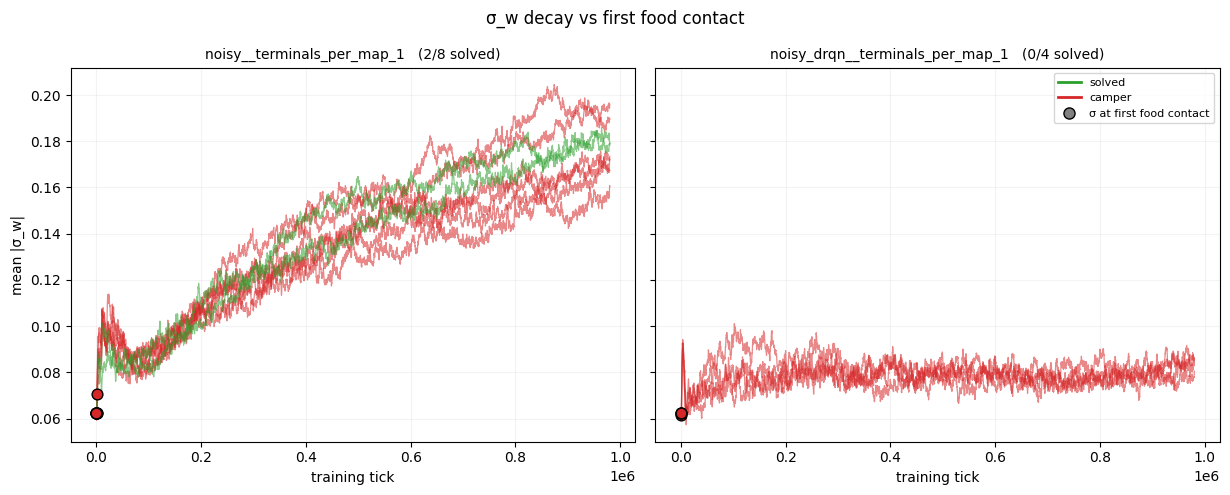

c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\prototypes\05_generalisation\plot_fn_v5.py:280: RuntimeWarning: All-NaN slice encountered
  lo = min(np.nanmin(comfort), np.nanmin(reward)) - 0.08
c:\Users\Adarsh Arun\Downloads\homeostatic-agents-main\prototypes\05_generalisation\plot_fn_v5.py:281: RuntimeWarning: All-NaN slice encountered
  hi = max(np.nanmax(comfort), np.nanmax(reward)) + 0.08


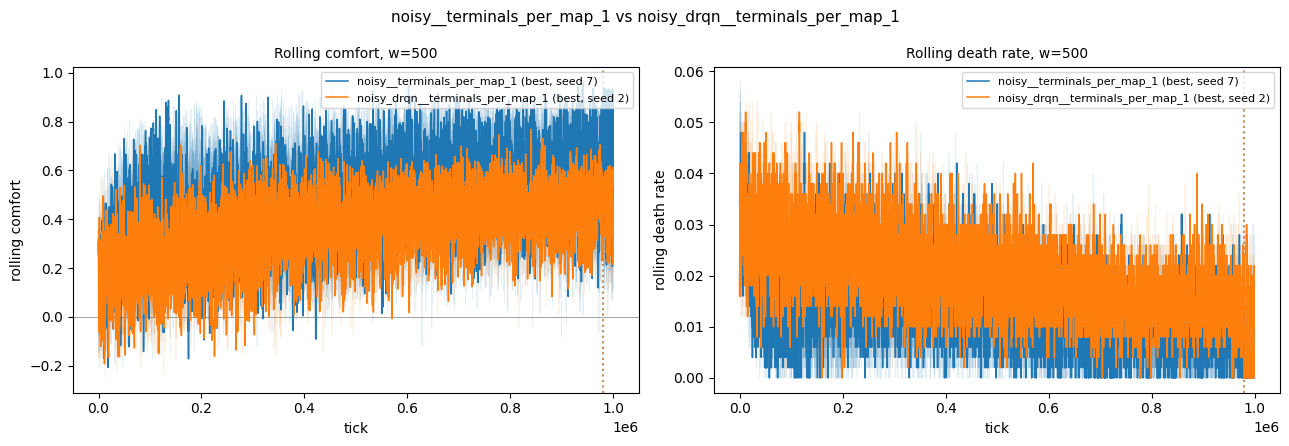

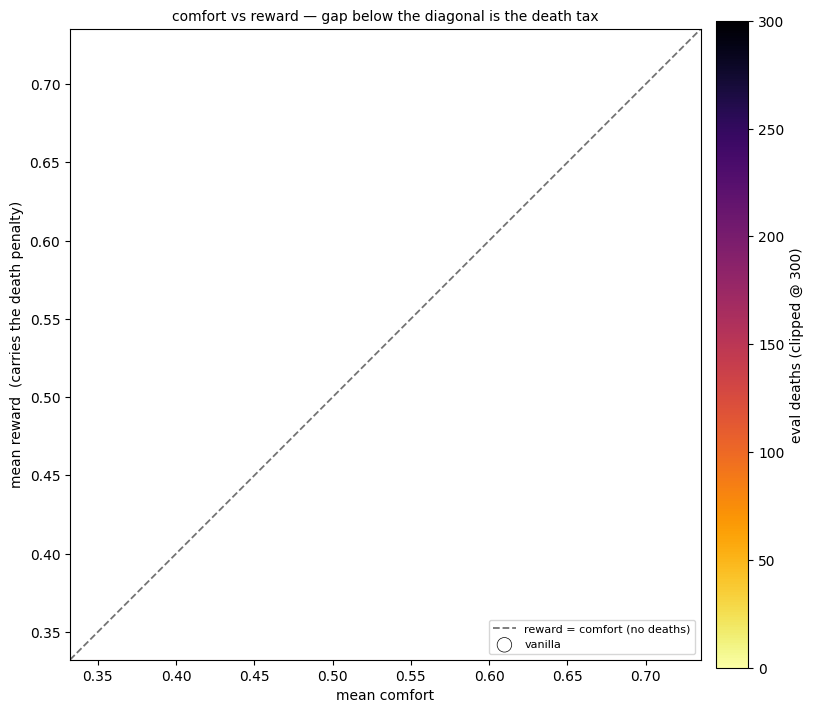

C:\Users\Adarsh Arun\AppData\Local\Temp\ipykernel_6008\2253802598.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


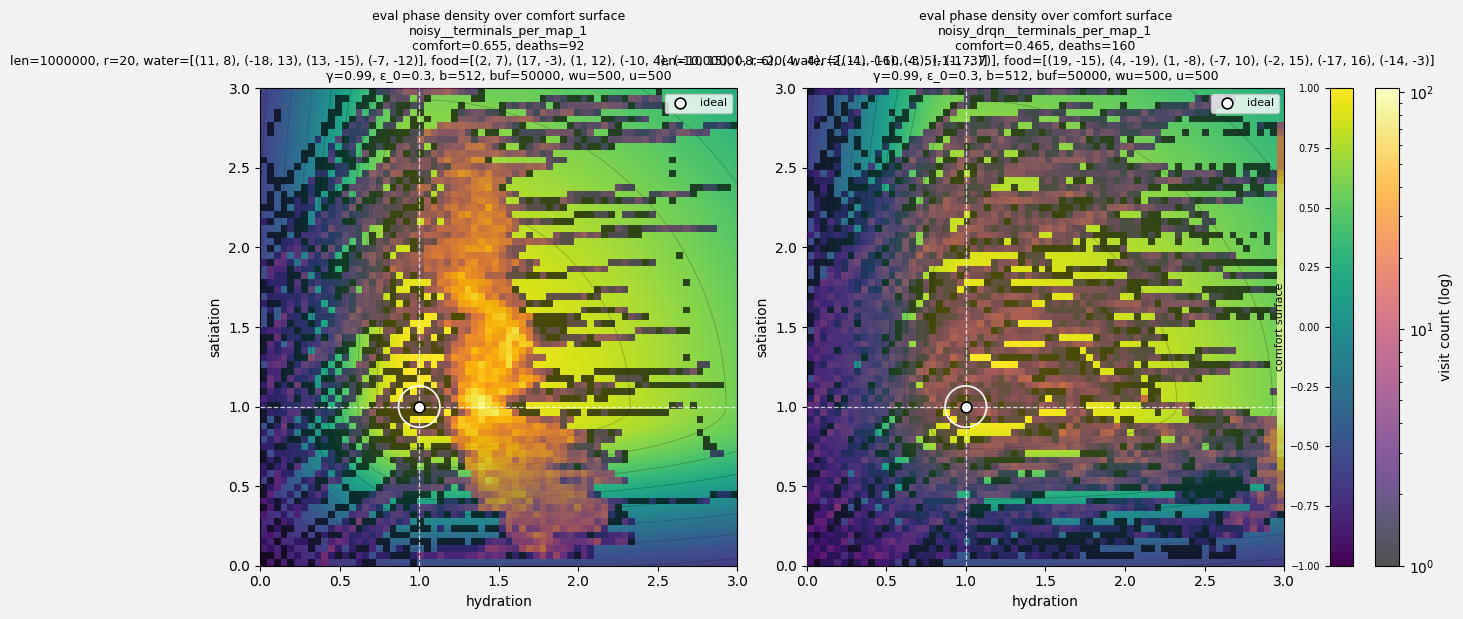

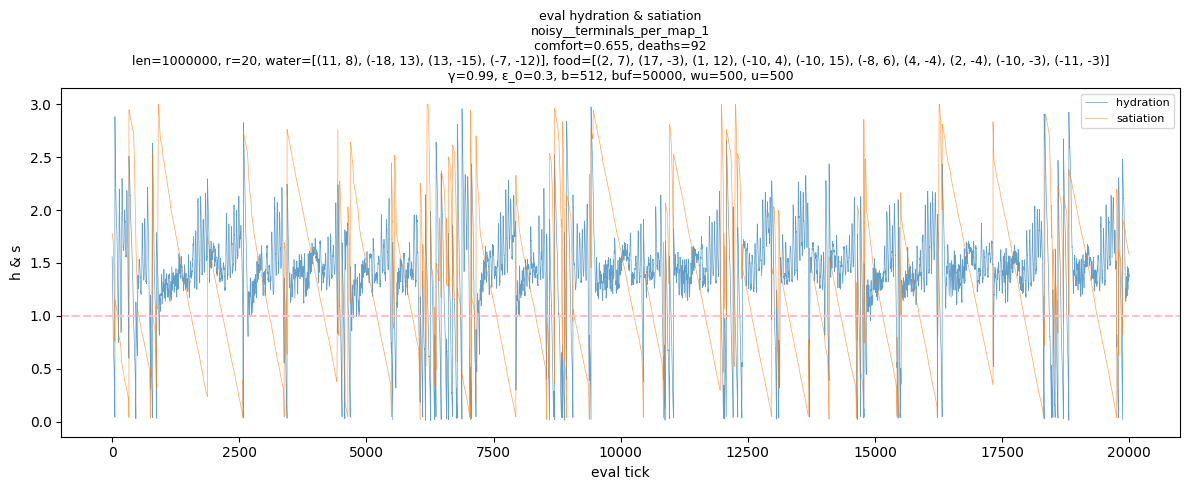

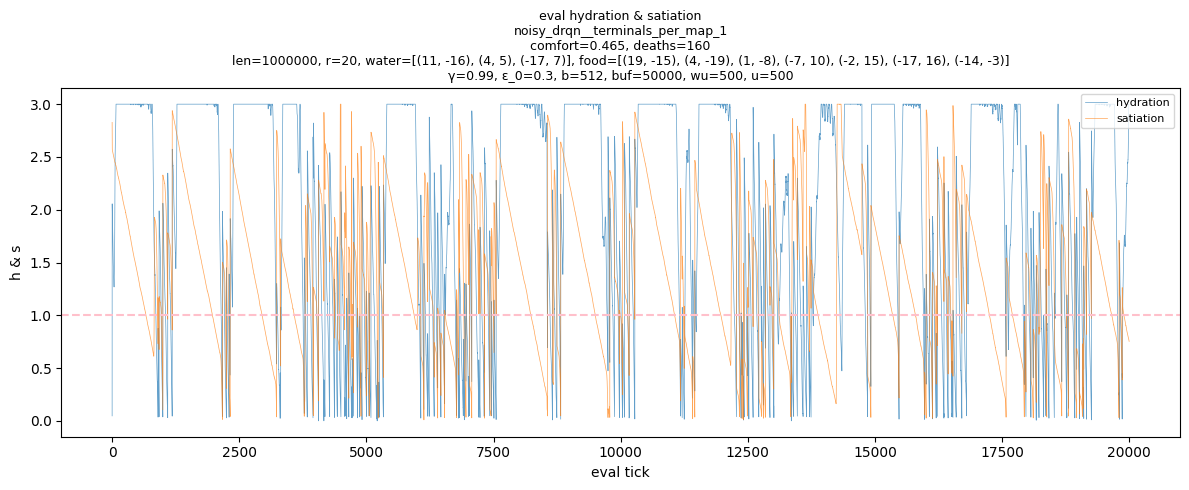

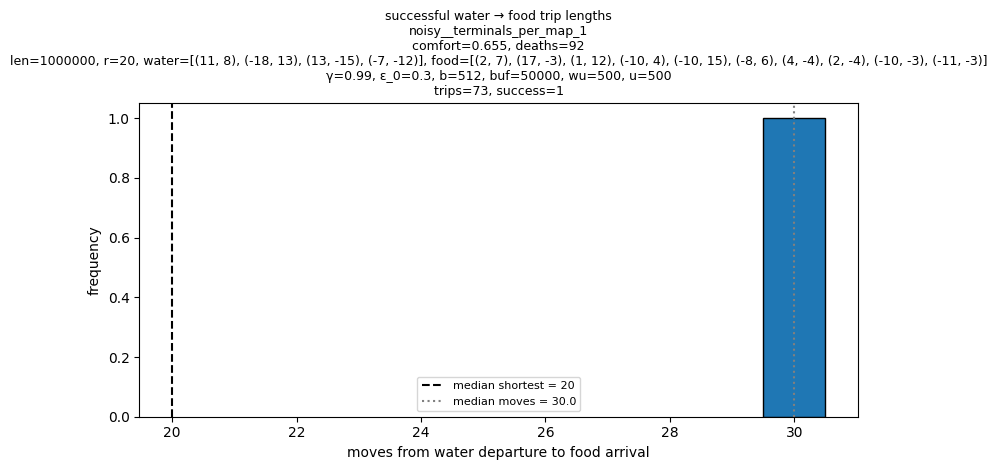

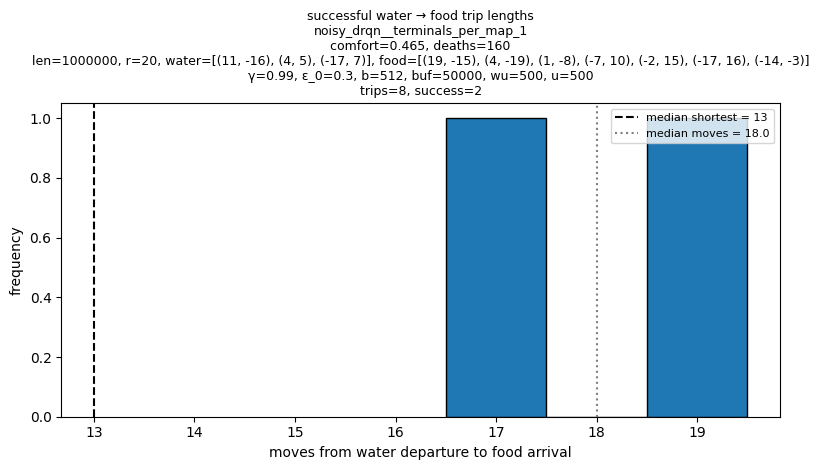

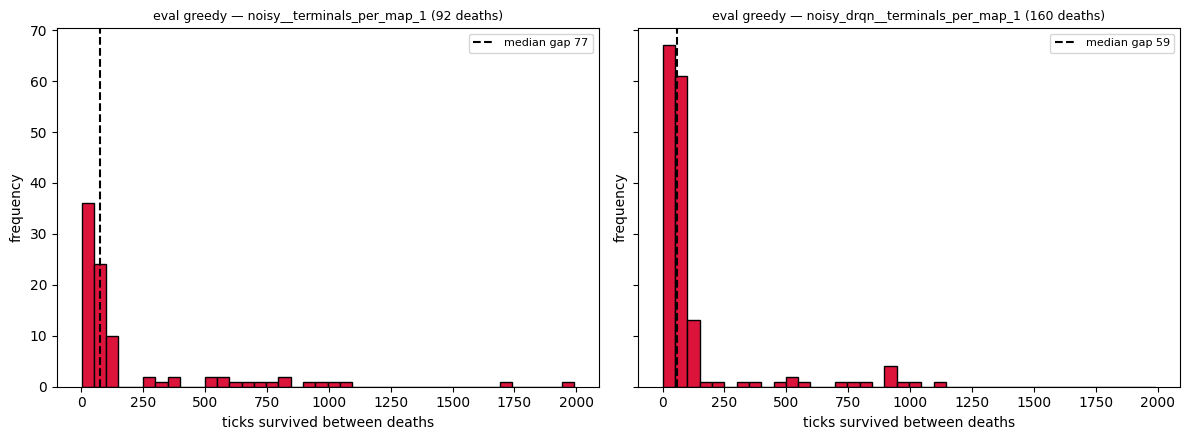

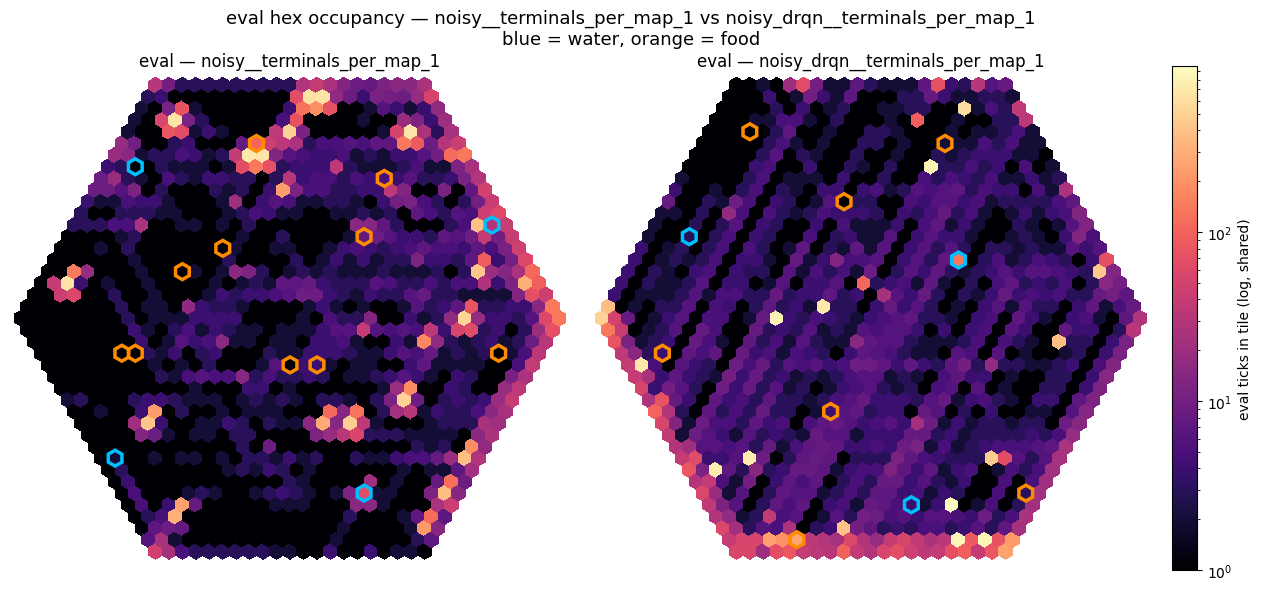

In [7]:
#region PLOT COMPARISON
from plot_fn_v5 import *
import numpy as np

import matplotlib.pyplot as plt

def print_available_configs():
    print("available configs:")

    for i, name in enumerate(res.keys()):
        ranked = res[name]["ranked"]
        median = res[name]["median"]

        print(
            f"{i}: {name} | "
            f"n={len(ranked)} | "
            f"median comfort={median['mean_comfort']:.3f} | "
            f"median-run deaths={median['death_count_eval']}"
        )

def choose_configs():
    names = list(res.keys())

    print_available_configs()
    sel = input("Select runs, comma-separated e.g. 0,1: ")

    idxs = [int(x.strip()) for x in sel.split(",") if x.strip() != ""]

    if len(idxs) < 1:
        raise ValueError("Select at least one config.")

    for i in idxs:
        if i < 0 or i >= len(names):
            raise IndexError(f"Config index out of range: {i}")

    return [names[i] for i in idxs]


NAMES = choose_configs()
PICK = "best"


plot_sigma_decay_compare(NAMES, res_obj=res)

def rolling_mean(x, window):
    x = np.asarray(x, dtype=float)

    if window <= 0:
        raise ValueError("window must be positive")

    if len(x) < window:
        return np.array([])

    c = np.cumsum(np.insert(x, 0, 0.0))
    return (c[window:] - c[:-window]) / window


def draw_rolling(ax, series, key, window, ymarks=()):
    # background seed haze
    for s in series:
        for run in s["bg"]:
            ax.plot(
                rolling_mean(run[key], window),
                color=s["haze"],
                lw=0.6,
                alpha=0.12,
                zorder=1,
            )

    # selected representative run
    for s in series:
        run = s["run"]
        ax.plot(
            rolling_mean(run[key], window),
            color=s["color"],
            lw=1.1,
            zorder=3,
            label=s["label"],
        )

        eb_roll = max(0, eb_of(run) - window + 1)
        ax.axvline(
            eb_roll,
            ls=":",
            c=s["color"],
            alpha=0.6,
            zorder=2,
        )

    for y in ymarks:
        ax.axhline(y, ls="-", c="black", lw=0.5, alpha=0.5)

    ax.legend(fontsize=8, loc="upper right")



def safe_fig_name(prefix, names):
    joined = "_vs_".join(names)
    joined = joined.replace(" ", "_").replace("/", "-").replace("//", "-")
    return f"{prefix}_{joined}"


def build_comparison_series(names, pick, colors):
    picked = [(name, pick_run(name, pick=pick, res_obj=res)) for name in names]

    series = []
    for i, (name, run) in enumerate(picked):
        color = colors[i % len(colors)]
        haze = color if len(picked) > 1 else "gray"

        series.append({
            "bg": res[name]["ranked"],
            "run": run,
            "color": color,
            "haze": haze,
            "label": f"{name} ({pick}, seed {run['seed']})",
        })

    return picked, series


def plot_comparison(
    names,
    pick="median",
    window=500,
    save=False,
    colors=("tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"),
):
    picked, series = build_comparison_series(names, pick, colors)

    # rolling comfort + death rate
    fig, (ax_c, ax_d) = plt.subplots(1, 2, figsize=(13, 4.5))

    draw_rolling(ax_c, series, "comfort_T", window, ymarks=(0,))
    ax_c.set_title(f"Rolling comfort, w={window}", fontsize=10)
    ax_c.set_xlabel("tick")
    ax_c.set_ylabel("rolling comfort")

    draw_rolling(ax_d, series, "death_T", window)
    ax_d.set_title(f"Rolling death rate, w={window}", fontsize=10)
    ax_d.set_xlabel("tick")
    ax_d.set_ylabel("rolling death rate")

    fig.suptitle(" vs ".join(names), fontsize=11)
    plt.tight_layout()

    plot_comfort_vs_reward(NAMES, res_obj=res)       # or just your selected ones

    if save:
        _save_fig(fig, safe_fig_name("cmp_rolling", names))

    plt.show()

    # phase density
    from matplotlib.gridspec import GridSpec

    n = len(picked)
    fig = plt.figure(figsize=(6.8 * n + 1.4, 6.2))
    gs  = GridSpec(1, n + 2,
                width_ratios=[*([1] * n), 0.045, 0.045],
                wspace=0.08, figure=fig)

    plot_axes  = [fig.add_subplot(gs[0, i]) for i in range(n)]
    cax_surf   = fig.add_subplot(gs[0, n])
    cax_dens   = fig.add_subplot(gs[0, n + 1])

    surf_m = dens_m = None
    for (name, run), ax in zip(picked, plot_axes):
        s, d = plot_phase_heatmap(run, name=name, ax=ax)
        surf_m = surf_m or s
        dens_m = dens_m or d          # first non-None density scale wins

    cbar_s = fig.colorbar(surf_m, cax=cax_surf)
    cbar_s.ax.yaxis.set_ticks_position('left')
    cbar_s.ax.yaxis.set_label_position('left')
    cbar_s.set_label("comfort surface", fontsize=8)
    cbar_s.set_ticks(np.linspace(-1, 1, 9))
    cbar_s.ax.tick_params(labelsize=7)

    if dens_m is not None:
        cbar_d = fig.colorbar(dens_m, cax=cax_dens)
        cbar_d.set_label("visit count (log)")

    plt.tight_layout()
    plt.show()

    # per-run diagnostics
    for name, run in picked:
        plot_eval_hs(run, name=name, save=save)

    for name, run in picked:
        plot_trip_lengths(run, name=name, save=save)

    # comparison diagnostics
    plot_death_gaps_eval_compare(picked, save=save)
    plot_hex_eval_compare(picked, save=save)


plot_comparison(NAMES, pick=PICK, window=500)

#endregion

In [ ]:
#region SUMMARY BLOCK

def fmt_pct(x, digits=1):
    if pd.isna(x):
        return "nan"
    return f"{100*x:.{digits}f}%"

def fmt_runtime(x):
    if pd.isna(x):
        return "nan"
    if "fmt_time" in globals():
        return fmt_time(x)
    return f"{x:.1f}s"

def fmt_num(x, digits=3):
    if pd.isna(x):
        return "nan"
    return f"{x:.{digits}f}"


def print_final_sweep_summary(summary_df, runs_df, experiment_name, PROTOTYPE_NAME):
    if summary_df.empty:
        print("No summary data loaded.")
        return

    print("=" * 90)
    print(f"FINAL SWEEP SUMMARY: {experiment_name}")
    print("=" * 90)

    print("\nConfigs tested:")
    print(f"  configs: {summary_df['config'].nunique()}")
    print(f"  total runs: {len(runs_df)}")
    print(f"  seeds per config: {int(summary_df['n_seeds'].median())}")

    print("\nCompact summary table:")
    cols = [
        "config",
        "n_seeds",
        "sim_len",
        "run_time_seconds_median",
        #"seconds_per_100k_ticks_median",
        #"ticks_per_second_median",
        "mean_comfort_median",
        "mean_comfort_std",
        "eval_deaths_median",
        "zero_death_rate",
        "food_visit_pct_median",
        "water_visit_pct_median",
        "path_efficiency_median",
        "perfectish_trip_rate_median",
        "solved_rate",
    ]

    table = summary_df[cols].copy()

    table["mean_comfort_median"] = table["mean_comfort_median"].map(lambda x: round(x, 3))
    table["mean_comfort_std"] = table["mean_comfort_std"].map(lambda x: round(x, 3) if not pd.isna(x) else np.nan)
    table["eval_deaths_median"] = table["eval_deaths_median"].map(lambda x: round(x, 1))
    table["zero_death_rate"] = table["zero_death_rate"].map(lambda x: f"{100*x:.0f}%")
    table["food_visit_pct_median"] = table["food_visit_pct_median"].map(lambda x: round(x, 1))
    table["water_visit_pct_median"] = table["water_visit_pct_median"].map(lambda x: round(x, 1))
    table["path_efficiency_median"] = table["path_efficiency_median"].map(lambda x: round(x, 3) if not pd.isna(x) else np.nan)
    table["perfectish_trip_rate_median"] = table["perfectish_trip_rate_median"].map(lambda x: f"{100*x:.0f}%" if not pd.isna(x) else "nan")
    table["solved_rate"] = table["solved_rate"].map(lambda x: f"{100*x:.0f}%")
    table["run_time_seconds_median"] = table["run_time_seconds_median"].map(fmt_runtime)
    #table["seconds_per_100k_ticks_median"] = table["seconds_per_100k_ticks_median"].map(lambda x: round(x, 2) if not pd.isna(x) else np.nan)
    #table["ticks_per_second_median"] = table["ticks_per_second_median"].map(lambda x: round(x, 1) if not pd.isna(x) else np.nan)

    print(table.to_string(index=False))

    print("\n" + "-" * 90)
    print("Winners / notable configs")
    print("-" * 90)

    best_comfort = summary_df.sort_values(
        ["mean_comfort_median", "mean_comfort_std"],
        ascending=[False, True],
    ).iloc[0]

    best_stability = summary_df.sort_values(
        ["mean_comfort_std", "mean_comfort_median"],
        ascending=[True, False],
    ).iloc[0]

    best_deaths = summary_df.sort_values(
        ["zero_death_rate", "eval_deaths_median", "mean_comfort_median"],
        ascending=[False, True, False],
    ).iloc[0]

    best_path = summary_df.sort_values(
        ["path_efficiency_median", "perfectish_trip_rate_median", "mean_comfort_median"],
        ascending=[False, False, False],
    ).iloc[0]

    best_solved = summary_df.sort_values(
        ["solved_rate", "mean_comfort_median", "path_efficiency_median"],
        ascending=[False, False, False],
    ).iloc[0]

    #best_runtime_efficiency = summary_df.sort_values(
    #["seconds_per_100k_ticks_median", "mean_comfort_median"],
    #ascending=[True, False],
    #).iloc[0]

    print(f"\nBest median comfort:")
    print(f"  {best_comfort['config']}")
    print(f"  median comfort = {best_comfort['mean_comfort_median']:.3f}")
    print(f"  std comfort    = {best_comfort['mean_comfort_std']:.3f}")

    print(f"\nMost stable comfort:")
    print(f"  {best_stability['config']}")
    print(f"  std comfort    = {best_stability['mean_comfort_std']:.3f}")
    print(f"  median comfort = {best_stability['mean_comfort_median']:.3f}")

    print(f"\nBest death robustness:")
    print(f"  {best_deaths['config']}")
    print(f"  zero-death rate     = {100*best_deaths['zero_death_rate']:.0f}%")
    print(f"  median eval deaths  = {best_deaths['eval_deaths_median']:.1f}")

    print(f"\nBest path efficiency:")
    print(f"  {best_path['config']}")
    print(f"  path efficiency        = {best_path['path_efficiency_median']:.3f}")
    print(f"  perfect-ish trip rate  = {100*best_path['perfectish_trip_rate_median']:.0f}%")

    print(f"\nBest overall solved rate:")
    print(f"  {best_solved['config']}")
    print(f"  solved rate      = {100*best_solved['solved_rate']:.0f}%")
    print(f"  median comfort   = {best_solved['mean_comfort_median']:.3f}")
    print(f"  path efficiency  = {best_solved['path_efficiency_median']:.3f}")
    print(f"\nBest runtime efficiency:")
    #print(f"  {best_runtime_efficiency['config']}")
    #print(f"  seconds per 100k      = {best_runtime_efficiency['seconds_per_100k_ticks_median']:.2f}")
    #print(f"  median comfort        = {best_runtime_efficiency['mean_comfort_median']:.3f}")

    print("\n" + "-" * 90)

    print("\nSaved files:")
    out = sweep_dir(experiment_name, PROTOTYPE_NAME=PROTOTYPE_NAME)
    print(f"  runs CSV:    {out / 'runs_df.csv'}")
    print(f"  summary CSV: {out / 'summary_df.csv'}")


print_final_sweep_summary(summary_df, runs_df, EXPERIMENT_NAME, PROTOTYPE_NAME=PROTOTYPE_NAME)

#endregion